# PESSD

## Requirements

In [2]:
pip install jupyterlab anywidget tempdisagg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 89.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 71.4 MB/s eta 0:00:00


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import pandas_datareader.data as web
import datetime
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from tempdisagg import TempDisaggModel
import pandas as pd
import statsmodels.api as sm

## Data

Comparaison des données dispos dans la base EA-MD-QD

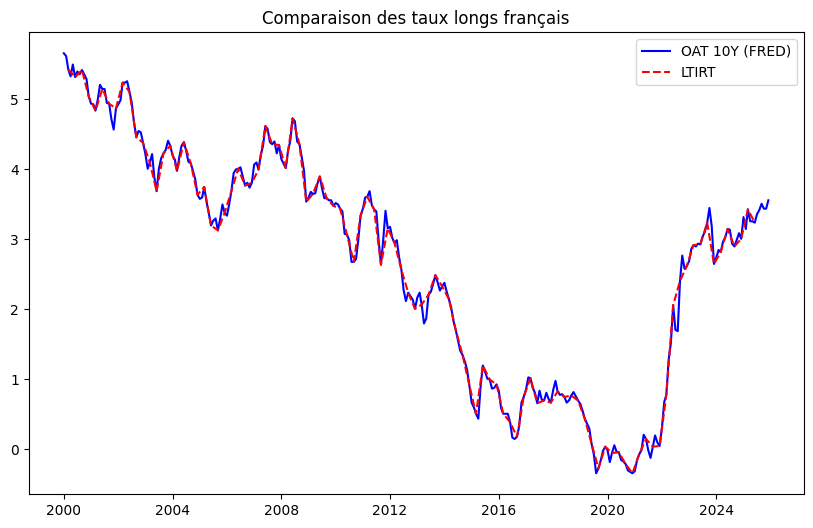

In [4]:
start = datetime.datetime(2000, 1, 1)
end = datetime.datetime(2025, 12, 31)
oat_fred = web.DataReader('IRLTLT01FRM156N', 'fred', start, end)

data_fr_raw = pd.read_excel("FRdata.xlsx", sheet_name="data", index_col=0, parse_dates=True)
data_fr = data_fr_raw.copy().drop(columns=['ICONFIX_FR','CCONFIX_FR','ESENTIX_FR','KCONFIX_FR','RTCONFIX_FR','SCONFIX_FR','BCI_FR','CCI_FR'],errors='ignore').dropna()
ltirt = data_fr['LTIRT_FR']


plt.figure(figsize=(10, 6))
plt.plot(oat_fred.index, oat_fred['IRLTLT01FRM156N'], label='OAT 10Y (FRED)', color='blue')
plt.plot(ltirt.index, ltirt, label='LTIRT', color='red', linestyle='--')
plt.title("Comparaison des taux longs français")
plt.legend()
plt.show()

On voit que c'est 99% similaire, donc top !

### Transformation en monthly

In [7]:
def from_quarterly_to_monthly(dataset, info, method="ensemble"):
    quaterly_colomns = info.loc[dataset.columns]["Frequency"] == "Q"
    monthly_colomns = info.loc[dataset.columns]["Frequency"] == "M"
    stock_flux_info = info.loc[dataset.columns]["Type"]
    conversion_type = {"S": "average", "F": "average"}

    mapping = {}
    for q_col in dataset.columns[quaterly_colomns]:
        best_corr = 0
        best_m_col = None
        for m_col in dataset.columns[monthly_colomns]:
            if stock_flux_info[q_col] == stock_flux_info[m_col]:
                corr = (dataset[q_col].resample("QE").mean()).corr(
                    dataset[m_col].resample("QE").mean()
                )
                if abs(corr) > abs(best_corr):
                    best_corr = corr
                    best_m_col = m_col
        mapping[q_col] = best_m_col

    result = {}
    index = (dataset.index).to_series().apply(lambda x: x.year).values
    grain = [i % 12 + 1 for i in range(len(index))]

    for q_col, m_col in mapping.items():
        series_type = stock_flux_info[q_col]
        if m_col is None:
            model = TempDisaggModel(method=method, conversion=conversion_type[series_type])
            # Ajout de la constante X: 1.0 pour l'absence d'indicateur
            df = pd.DataFrame({"Index": index, "Grain": grain, "y": dataset[q_col], "X": 1.0})
            model.fit(df)
            y_m = model.predict()
        else:
            model = TempDisaggModel(method=method, conversion=conversion_type[series_type])
            df = pd.DataFrame({
                "Index": index, "Grain": grain, "y": dataset[q_col], "X": dataset[m_col]
            })
            model.fit(df)
            y_m = model.predict()
        result[q_col] = y_m

    m_index = dataset.index
    results_flat = {k: np.asarray(v).reshape(-1) for k, v in result.items()}
    df_q_to_m = pd.DataFrame.from_dict(results_flat, orient="columns")
    df_q_to_m = df_q_to_m[: len(m_index)]
    df_q_to_m.index = m_index[: len(df_q_to_m)]

    df_final = pd.concat([df_q_to_m, dataset.loc[:, monthly_colomns]], axis=1)
    return df_final

In [ ]:
# ==============================================================================
# FRANCE
# ==============================================================================
data_fr = pd.read_excel("data\\FRdata.xlsx", sheet_name="data", index_col=0, parse_dates=True)
info_fr = pd.read_excel("data\\FRdata.xlsx", sheet_name="info", index_col=0)

df_fr_monthly = from_quarterly_to_monthly(data_fr, info_fr)
df_fr_monthly.dropna(how="all", inplace=True)

info_fr_monthly = info_fr.copy()
info_fr_monthly.loc[info_fr_monthly["Frequency"] == "Q", "Frequency"] = "M"
info_fr_monthly.drop(columns=["Type"], inplace=True)

with pd.ExcelWriter("data\\FRdata_monthly.xlsx") as writer: #, engine="xlsxwriter"
    df_fr_monthly.to_excel(writer, sheet_name="data", index=True)
    info_fr_monthly.to_excel(writer, sheet_name="info", index=True)

print("Traitement terminé pour la France. Fichier 'FRdata_monthly.xlsx' généré.")

Traitement terminé pour la France. Fichier 'FRdata_monthly.xlsx' généré.


In [ ]:
# ==============================================================================
# ALLEMAGNE
# ==============================================================================
data_de = pd.read_excel("data\\DEdata.xlsx", sheet_name="data", index_col=0, parse_dates=True)
info_de = pd.read_excel("data\\DEdata.xlsx", sheet_name="info", index_col=0)

df_de_monthly = from_quarterly_to_monthly(data_de, info_de)
df_de_monthly.dropna(how="all", inplace=True)

info_de_monthly = info_de.copy()
info_de_monthly.loc[info_de_monthly["Frequency"] == "Q", "Frequency"] = "M"
info_de_monthly.drop(columns=["Type"], inplace=True)

with pd.ExcelWriter("data\\DEdata_monthly.xlsx") as writer: #, engine="xlsxwriter"
    df_de_monthly.to_excel(writer, sheet_name="data", index=True)
    info_de_monthly.to_excel(writer, sheet_name="info", index=True)

print("Traitement terminé pour l'Allemagne. Fichier 'DEdata_monthly.xlsx' généré.")

Traitement terminé pour l'Allemagne. Fichier 'DEdata_monthly.xlsx' généré.


Il faut process les données grâce au fichier de la BDD pour tout stationnariser (ou alors tout refaire à la main). Pour l'instant j'ai choisi de faire les "Heavy Transformation".

In [ ]:
data_fr = pd.read_excel("data\\FRdataM_HT.xlsx", sheet_name="FR", index_col=0, parse_dates=True)
data_de = pd.read_excel("data\\DEdataM_HT.xlsx", sheet_name="DE", index_col=0, parse_dates=True)

# Normalement inutile, mais il faut assurer le coup.
if 'LTIRT_FR' not in data_fr.columns:
    data_fr = data_fr.add_suffix('_FR')
if 'LTIRT_DE' not in data_de.columns:
    data_de = data_de.add_suffix('_DE')

# Création d'une base FR+DE
data_joint = data_fr.join(data_de, how='inner')

# On supprime les variables de sentiment de notre base (normalement elles sont toutes là)
sentiment_vars_base = ['ICONFIX', 'CCONFIX', 'ESENTIX', 'KCONFIX', 'RTCONFIX', 'SCONFIX', 'BCI', 'CCI']
cols_to_drop = []

for var in sentiment_vars_base:
    cols_to_drop.extend([f"{var}_FR", f"{var}_DE"])

# On vérifie quelles variables présentes avant de les supprimer
cols_to_drop = [c for c in cols_to_drop if c in data_joint.columns]
data_joint_no_sentiment = data_joint.drop(columns=cols_to_drop)

# On nettoie la base finale
data_joint_clean = data_joint_no_sentiment.dropna()

# On créer un fichier pour éviter de refaire ça.
data_joint_clean.to_csv("data\\Joint_Macro_Dataset.csv")

print(f"Dimensions de la base conjointe : {data_joint_clean.shape[0]} mois et {data_joint_clean.shape[1]} variables.")
print(f"Variables de sentiment retirées : {len(cols_to_drop)}")
print("Fichier créé !")

Dimensions de la base conjointe : 308 mois et 64 variables.
Variables de sentiment retirées : 16
Fichier créé !


## Traitement

Là l'idée c'est de faire un Factor modèle à partir des données dispos en excluant les indicateurs de confiances !

Donc ici notre $y_t$ c'est directement le spread (France - Allemagne, mais a ajuster au besoin), et les variables explicatives seront les $n$ variables issues de la PCA.

Bon au final les algos choisissent souvent n=1 ou n=2 mais comme on l'a vu avec Perogaro, on s'attend plus à du 3-4 d'après Nelson-Siegal, donc je pars là dessus mais ça reste flexible.

Donc on part sur la régression :

$$y_t = \beta_0 + \beta_1 F_{1,t} + \beta_2 F_{2,t} + \beta_3 F_{3,t} + \beta_4 F_{4,t} + \epsilon_t$$

Et ici ce dont on aura besoin c'est ce $\epsilon_t$ pour utiliser notre sentiment.

In [ ]:
# On peut directement recharcher le fichier sans avoir à tout relancer
data_joint = pd.read_csv("data\\Joint_Macro_Dataset.csv", index_col=0, parse_dates=True)

In [ ]:
# On récupère les taux directement des bases initiales (non transformées)
# On peut aussi utiliser FRED si c'est plus pratique
raw_fr = pd.read_excel("data\\FRdata_monthly.xlsx", sheet_name="data", index_col=0, parse_dates=True)
raw_de = pd.read_excel("data\\DEdata_monthly.xlsx", sheet_name="data", index_col=0, parse_dates=True)

# On créer notre spread
spread_brut = raw_fr['LTIRT_FR'] - raw_de['LTIRT_DE']
spread_brut.name = "Spread_OAT_BUND"

# On oublie pas de retirer les taux de la base cible...
cols_to_drop = ['LTIRT_FR', 'LTIRT_DE']
sentiment_vars_base = ['ICONFIX', 'CCONFIX', 'ESENTIX', 'KCONFIX', 'RTCONFIX', 'SCONFIX', 'BCI', 'CCI']
for var in sentiment_vars_base:
    cols_to_drop.extend([f"{var}_FR", f"{var}_DE"])

cols_to_drop_existing = [c for c in cols_to_drop if c in data_joint.columns]
X_macro = data_joint.drop(columns=cols_to_drop_existing)

# On créer la 1st diff du spread pour rester cohérent
spread_diff = spread_brut.diff().dropna()
spread = spread_diff.loc[X_macro.index]
spread.name = "Delta_Spread_OAT_BUND"

# Je crois qu'il faut vérifier que j'ai les bonnes données mais ça changera pas grand chose en soit
print(f"Nombre de variables macro utilisées pour la PCA : {X_macro.shape[1]}")


Nombre de variables macro utilisées pour la PCA : 62


In [16]:
# Calcul de la PCA

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_macro)

# On impose 4 facteurs (Niveau, Pente, Courbure, etc.)
pca = PCA(n_components=4)
factors = pca.fit_transform(X_scaled)

print(f"Variance macro expliquée par les 4 facteurs : {pca.explained_variance_ratio_.sum()*100:.2f}%\n")

# On stock
df_factors = pd.DataFrame(factors, index=X_macro.index, columns=['F1', 'F2', 'F3', 'F4'])


Variance macro expliquée par les 4 facteurs : 42.84%



In [ ]:
# Régression + correction de l'autocorrelation (NEWEY-WEST)
X_reg = sm.add_constant(df_factors)
model = sm.OLS(spread, X_reg).fit(cov_type='HAC', cov_kwds={'maxlags': 3})

print("--- RÉSULTATS DE LA RÉGRESSION ---")
print(model.summary())

--- RÉSULTATS DE LA RÉGRESSION ---
                              OLS Regression Results                             
Dep. Variable:     Delta_Spread_OAT_BUND   R-squared:                       0.032
Model:                               OLS   Adj. R-squared:                  0.020
Method:                    Least Squares   F-statistic:                     3.070
Date:                   Sun, 08 Mar 2026   Prob (F-statistic):             0.0168
Time:                           16:31:46   Log-Likelihood:                 398.85
No. Observations:                    308   AIC:                            -787.7
Df Residuals:                        303   BIC:                            -769.0
Df Model:                              4                                         
Covariance Type:                     HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------

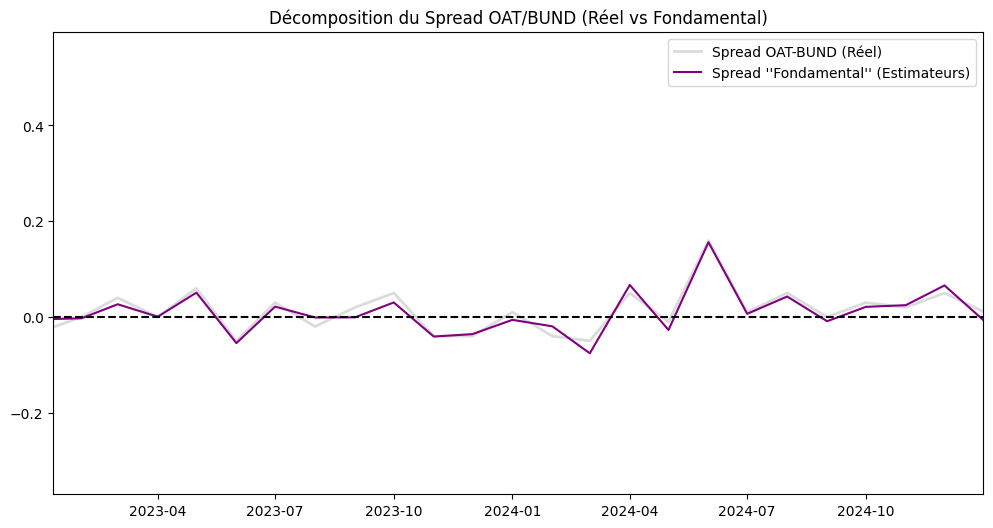

In [26]:
# On plot
residuals = model.resid
residuals.name = "Epsilon_Spread"

# Pour choisir la plage
date_debut = datetime.date(2023, 1, 10)
date_fin = datetime.date(2024, 12, 31)

plt.figure(figsize=(12, 6))
plt.plot(spread.index, spread, label="Spread OAT-BUND (Réel)", color='lightgray', alpha=0.8, linewidth=2)
plt.plot(residuals.index, residuals, label="Spread ''Fondamental'' (Estimateurs)", color='purple', linewidth=1.5)
plt.axhline(0, color='black', linestyle='--')
plt.title("Décomposition du Spread OAT/BUND (Réel vs Fondamental)")
plt.xlim([date_debut, date_fin])
plt.legend()
plt.show()

In [ ]:
# On exporte pour tout avoir à dispo
residuals.to_csv("epsilon_spread.csv")
print("\nRésidus sauvegardés dans 'epsilon_spread.csv'.")


Résidus sauvegardés dans 'epsilon_spread.csv'.


Je compte rajouter des meilleurs graphs avec plotly ensuite